EXERCÍCIO BASE

In [7]:
# ── Importações ──────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [8]:
# ── Criação do Dataset ───────────────────────────────
np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":             ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

# Salva como CSV
df.to_csv("vendas_livraria.csv", index=False)

print(f"✅ Dataset criado! Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
df.head()

✅ Dataset criado! Shape: (50, 9)
   Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']


,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Atomic Habits,Autoajuda,3,44.9,Ana Lima,Centro-Oeste,134.7
1,2,2024-01-04,Python para Dados,Tecnologia,1,89.9,Fernanda Rocha,Norte,89.9
2,3,2024-01-08,A Arte da Guerra,Filosofia,4,32.0,Bruno Costa,Centro-Oeste,128.0
3,4,2024-01-12,Clean Code,Tecnologia,2,95.0,Bruno Costa,Nordeste,190.0
4,5,2024-01-15,Atomic Habits,Autoajuda,4,44.9,Carlos Mendes,Nordeste,179.6


In [9]:
# ── Exploração Inicial ───────────────────────────────
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("📋 INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n📊 TIPOS DE DADOS:")
print(df.dtypes)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
📋 INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

📊 TIPOS DE DADOS:
id_venda         int64
data               str
produto            str
categoria          str
quantidade       int64
preco_unit     float64
vendedor           str
regiao             str
total_venda    float64
dtype: object

🔍 VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

📈 ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,55.57,150.77
std,1.45,23.27,98.01
min,1.00,29.90,29.90
25%,2.00,36.90,79.80
50%,3.00,47.40,128.00
75%,4.00,62.50,190.00
max,5.00,95.00,475.00


In [10]:
# ── Análise de Vendas ────────────────────────────────

# 1. Total faturado
total = df["total_venda"].sum()
print(f"💰 Faturamento Total: R$ {total:,.2f}")

# 2. Faturamento por categoria
print("\n📦 Faturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

# 3. Melhor vendedor
print("\n🏆 Ranking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

# 4. Produto mais vendido (em quantidade)
print("\n📚 Top 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

# 5. Venda média por região
print("\n🗺️  Ticket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

💰 Faturamento Total: R$ 7,538.40

📦 Faturamento por Categoria:
categoria
Tecnologia    R$ 2,788.80
Autoajuda     R$ 1,122.50
Ciências      R$ 1,071.80
Literatura      R$ 813.90
Filosofia       R$ 704.00
Fantasia        R$ 648.70
Infantil        R$ 388.70
Name: total_venda, dtype: str

🏆 Ranking de Vendedores:
vendedor
Bruno Costa       R$ 3,392.90
Ana Lima          R$ 1,700.80
Fernanda Rocha    R$ 1,361.10
Carlos Mendes     R$ 1,083.60
Name: total_venda, dtype: str

📚 Top 3 Produtos (qtd vendida):
produto
Atomic Habits       25
A Arte da Guerra    22
Clean Code          18
Name: quantidade, dtype: int64

🗺️  Ticket Médio por Região:
regiao
Nordeste        R$ 178.94
Norte           R$ 164.88
Sudeste         R$ 135.95
Centro-Oeste    R$ 135.26
Sul             R$ 133.08
Name: total_venda, dtype: str


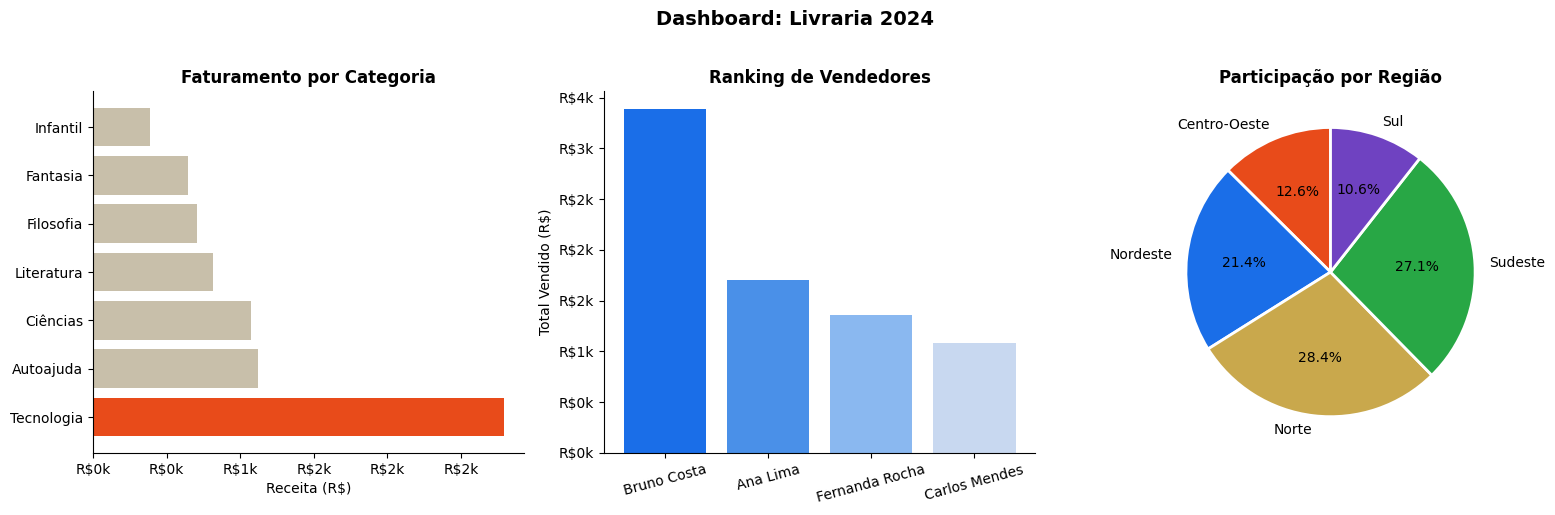

✅ Gráficos salvos em dashboard_livraria.png


In [11]:
# ── Visualizações ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

# --- Gráfico 1: Faturamento por Categoria (barras) ---
ax1 = axes[0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

# --- Gráfico 2: Ranking Vendedores (barras verticais) ---
ax2 = axes[1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

# --- Gráfico 3: Distribuição das Regiões (pizza) ---
ax3 = axes[2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficos salvos em dashboard_livraria.png")

DESAFIOS EXTRAS

1. Calcule a evolução do faturamento mês a mês

In [12]:
# 1. Converter a coluna "data" para o formato datetime
df['data'] = pd.to_datetime(df['data'])

# 2. Extrair o mês e criar uma nova coluna
df['mes'] = df['data'].dt.month

# 3. Calcular a evolução (soma do total_venda agrupado por mês)
faturamento_mensal = df.groupby('mes')['total_venda'].sum()

print("📈 Faturamento Mês a Mês:")
print(faturamento_mensal.apply(lambda x: f"R$ {x:,.2f}"))

📈 Faturamento Mês a Mês:
mes
1    R$ 1,251.40
2    R$ 1,281.10
3    R$ 1,505.60
4    R$ 1,284.40
5    R$ 1,263.50
6      R$ 952.40
Name: total_venda, dtype: str


2. Crie um gráfico de linha mostrando a tendência de vendas

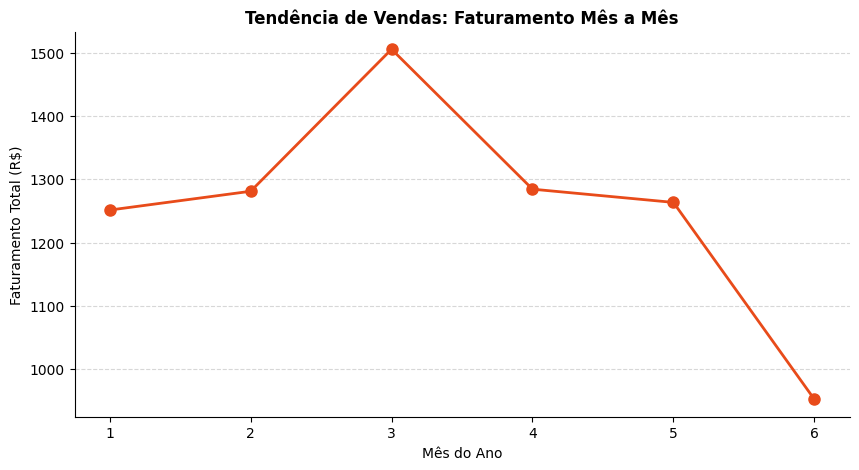

In [13]:
# Criando a figura e os eixos
plt.figure(figsize=(10, 5))

# Plotando a linha de tendência
plt.plot(faturamento_mensal.index, faturamento_mensal.values,
         marker='o', color='#e84b1a', linewidth=2, markersize=8)

# Configurações do gráfico
plt.title("Tendência de Vendas: Faturamento Mês a Mês", fontweight="bold")
plt.xlabel("Mês do Ano")
plt.ylabel("Faturamento Total (R$)")

# Ajustando o eixo X para mostrar apenas números inteiros (meses)
plt.xticks(faturamento_mensal.index)

# Adicionando uma grade sutil para facilitar a leitura
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

3. Descubra qual vendedor tem o maior ticket médio

In [14]:
# Agrupando por vendedor e calculando a média da coluna total_venda
ticket_medio = df.groupby('vendedor')['total_venda'].mean().sort_values(ascending=False)

print("🎯 Ticket Médio por Vendedor:")
print(ticket_medio.apply(lambda x: f"R$ {x:,.2f}"))

vendedor_destaque = ticket_medio.index[0]
print(f"\n🏆 O vendedor com o maior ticket médio é: {vendedor_destaque}")

🎯 Ticket Médio por Vendedor:
vendedor
Bruno Costa       R$ 161.57
Fernanda Rocha    R$ 151.23
Ana Lima          R$ 141.73
Carlos Mendes     R$ 135.45
Name: total_venda, dtype: str

🏆 O vendedor com o maior ticket médio é: Bruno Costa


4. Filtre apenas as vendas com total_venda > 200

In [15]:
# 1. Filtrar as vendas
vendas_alto_valor = df[df['total_venda'] > 200]

# 2. Analisar quais categorias dominam
categorias_dominantes = vendas_alto_valor.groupby('categoria')['total_venda'].sum().sort_values(ascending=False)

print("💎 Categorias que dominam as vendas de alto valor (> R$ 200):")
print(categorias_dominantes.apply(lambda x: f"R$ {x:,.2f}"))

💎 Categorias que dominam as vendas de alto valor (> R$ 200):
categoria
Tecnologia    R$ 1,859.20
Ciências        R$ 250.00
Fantasia        R$ 249.50
Autoajuda       R$ 224.50
Name: total_venda, dtype: str


5. Adicione 5 linhas com valores nulos no dataset e escreva código para identificá-los e tratá-los com

In [16]:
# 1. Criar um DataFrame com 5 linhas contendo valores nulos (NaN)
linhas_vazias = pd.DataFrame([{
    "id_venda": np.nan, "data": np.nan, "produto": np.nan,
    "categoria": np.nan, "quantidade": np.nan, "preco_unit": np.nan,
    "vendedor": np.nan, "regiao": np.nan, "total_venda": np.nan
}] * 5)

# 2. Adicionar as linhas ao dataset original usando pd.concat
df_sujo = pd.concat([df, linhas_vazias], ignore_index=True)

print("🔍 Valores nulos antes do tratamento:")
print(df_sujo.isnull().sum())

print("-" * 30)

# 3. Identificar e tratar
df_sujo['quantidade'] = df_sujo['quantidade'].fillna(0)

print("\n✨ Valores nulos após o tratamento (removendo linhas 100% vazias):")
print(df_limpo.isnull().sum())

🔍 Valores nulos antes do tratamento:
id_venda       5
data           5
produto        5
categoria      5
quantidade     5
preco_unit     5
vendedor       5
regiao         5
total_venda    5
mes            5
dtype: int64
------------------------------

✨ Valores nulos após o tratamento (removendo linhas 100% vazias):


NameError: name 'df_limpo' is not defined